# NN Dataset Generation for TAG Authentication (v3 — DNN Input)

**Objective**: Generate dataset for authentication using raw equalized signal y/h.

- **DNN input (y_eq)**: equalized signal vector y/h of length L_FIXED=1024 (zero-padded)
- **Classical input (tau_eq)**: correlator scalar |Σ(y/h − ρ_s·msg)·tag_ref| / ρ_t (Xie 2021)
- **Labels**: H1=1 (authentic — message WITH legitimate TAG) vs H0=0 (fraudulent attacker — message transmitted WITHOUT any TAG)
- **SNR range**: 0–30 dB stratified (matches Xie 2021 Fig. 2)
- **Output**: HDF5 with y_eq, tau_eq, h, snr, labels — split 80/10/10

**Signal model**:
- H1 (authentic): y = h·(ρ_s·msg + ρ_t·tag) + w  →  y/h = ρ_s·msg + ρ_t·tag + w/h
- H0 (fraudulent attacker): y = h·msg + w  →  y/h = msg + w/h  — attacker transmits the raw message with **no TAG at all** (not even a fake/random one)

**η (bound on false-alarm probability, P_FA ≤ η)**: **η = 0.01**, matching Xie et al. (2021), Figs. 2–3 (ε_FA = 0.01). All D3F/closed-form threshold calculations in this notebook and downstream (NN_02b–NN_02e, NN_07) use this value.

**Architecture reference**: Chin & Chin (Eng. Proc. 2025) — 1D DNN for binary hypothesis testing (reference only — **DNN training via NN_02 is no longer executed**; current work focuses on DNN classifiers over engineered features / z_eq)
**Theory**: Braca et al. (2022) — D3F framework, ML converges to LRT under large-deviations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc, erfcinv
from scipy import stats
import h5py
import os
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print(f"Python version: {np.__version__}")
print(f"NumPy version: {np.__version__}")

# ============================================================================
# SETUP PATHS FOR NEW DIRECTORY STRUCTURE
# ============================================================================
from pathlib import Path

notebook_dir = Path.cwd()  # Current: notebooks/
project_root = notebook_dir.parent  # Go up to: Redes Neurais/
results_dir = project_root / "results"
data_dir = results_dir / "data"
visualizations_dir = results_dir / "Figures2"

# Ensure directories exist
data_dir.mkdir(parents=True, exist_ok=True)
visualizations_dir.mkdir(parents=True, exist_ok=True)

print(f"Project root: {project_root}")
print(f"Data directory: {data_dir}")
print(f"Visualizations directory: {visualizations_dir}")
# Xie et al. (2021), Fig. 3 reference parameters
XIE_L = 64
XIE_RHO_T2 = 0.1
XIE_RHO_T = np.sqrt(XIE_RHO_T2)
XIE_ALPHA = 0.01
XIE_SIGMA2_TAG = 1.0


Libraries imported successfully!
Python version: 2.2.6
NumPy version: 2.2.6
Project root: /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais
Data directory: /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/data
Visualizations directory: /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/Figures2


In [2]:
# ==============================================================================
# 2. CORE FUNCTIONS FOR TAG GENERATION & SIMULATION
# ==============================================================================

def modulator_bpsk(L, seed=None):
    if seed is not None:
        np.random.seed(seed)
    bits = np.random.randint(0, 2, L)
    return 2 * bits - 1  # {+1, -1}

def _tent(x, beta=1e-6):
    """Tent map on [-1, 1].
    Invariant measure: Uniform[-1,1]  →  E[x]=0, E[x²]=1/3.
    Matches Monte Carlo notebook implementation.
    """
    if x < beta:
        return 2.0 / (beta + 1) * x + (1.0 - beta) / (beta + 1)
    return 2.0 / (beta - 1) * x - (beta + 1) / (beta - 1)

def generate_tag(msg, key, L, K=70):
    """Generate chaotic TAG.  E[tag]=0, E[tag²]≈1/3  (matches MC notebook).

    Bugs fixed vs. original:
      1. seed = sum(msg*key) % 1 was always 0.0  (integer sum mod 1)
         → now uses XOR-bits → 64-bit int → quadratic map → [-1,1]
      2. Tent map was defined on [0,1]: from x=0 it diverged to -inf
         → replaced with MC tent map on [-1,1], zero-mean orbit
    """
    # Step 1 — seed: msg ±1 → bits, XOR with key, pack 64 bits → scalar in [-1,1]
    msg_bits = ((msg + 1) // 2).astype(np.uint8)          # ±1 → {0,1}
    n        = min(K, len(msg_bits), len(key))
    m_pad    = np.resize(msg_bits[:n], K)
    k_pad    = np.resize(key[:n].astype(np.uint8), K)
    xor_seq  = np.bitwise_xor(m_pad, k_pad)

    packed   = np.packbits(xor_seq[:64])                   # 64 bits → 8 bytes
    xor_int  = int.from_bytes(packed.tobytes(), 'big')
    xi       = (6 * xor_int**2 + xor_int + 1) % (2**64)
    x0       = (xi / (2**64 - 1)) * 2.0 - 1.0             # seed ∈ (-1, 1)

    # Step 2 — chaotic orbit on [-1,1]: discard warm_up, collect L points
    assert K > L
    warm_up = max(0, K - L)
    x = x0
    buf = np.empty(L, dtype=np.float64)
    k_out = 0
    for i in range(warm_up + L):
        x = _tent(x)
        if i >= warm_up:
            buf[k_out] = x
            k_out += 1

    # Step 3 — normalize: var(buf)=1/3  →  E[tag²]=1/3 (since E[tag]≈0)
    std_buf = buf.std()
    if std_buf > 1e-10:
        buf = buf / (std_buf * np.sqrt(3))

    return buf

def rayleigh_channel(length, sigma_h=1/np.sqrt(2)):
    real_part = np.random.normal(0, sigma_h, length)
    imag_part = np.random.normal(0, sigma_h, length)
    return np.sqrt(real_part**2 + imag_part**2)

def awgn_channel(signal, snr_db, ref_signal=None):
    """Adds AWGN calibrated to a NOMINAL (pre-fade) SNR.

    IMPORTANT (AÇÃO 2 fix): noise power is calibrated from `ref_signal`
    (the pre-fade transmitted signal x), NOT from `signal` itself. This
    matches the Xie 2021 / Monte Carlo convention (gen_awgn + add_noise in
    Simulações Monte Carlo/*.ipynb): noise power is fixed given snr_db,
    independent of the fading gain h. If `signal` already includes h (i.e.
    signal = h*x), passing ref_signal=x keeps the noise power h-independent,
    so the real received SNR = h² · snr_nominal has a genuine deep-fade
    tail (unlike the old convention, where noise was calibrated from h*x
    and h canceled out completely after equalization).
    """
    ref = signal if ref_signal is None else ref_signal
    snr_linear   = 10**(snr_db / 10)
    signal_power = np.mean(np.abs(ref)**2)
    noise_power  = signal_power / snr_linear
    noise = np.random.normal(0, np.sqrt(noise_power), len(signal))
    return signal + noise

# --- Quick validation ---
print("Core functions defined successfully!")
np.random.seed(0)
_msg = modulator_bpsk(70)
_key = np.random.randint(0, 2, 70)
_tag = generate_tag(_msg, _key, 64, K=70)
print(f"Tag validation (L=64, K=70):")
print(f"  mean  = {_tag.mean():.4f}  (expect ≈ 0)")
print(f"  var   = {_tag.var():.4f}  (expect ≈ 0.333)")
print(f"  E[t²] = {np.mean(_tag**2):.4f}  (expect ≈ 0.333)")
print(f"  min/max = {_tag.min():.3f} / {_tag.max():.3f}")

Core functions defined successfully!
Tag validation (L=64, K=70):
  mean  = -0.0237  (expect ≈ 0)
  var   = 0.3333  (expect ≈ 0.333)
  E[t²] = 0.3339  (expect ≈ 0.333)
  min/max = -0.968 / 0.975


In [3]:
# ==============================================================================
# 2b. BATCH TAG GENERATION (NumPy — sem dependência de torch)
# ==============================================================================
# A geração da TAG usa o mapa de tenda (tent map), uma operação escalar
# sequencial. Torch não traz ganho real aqui pois o laço de K iterações
# do mapa caótico é inerentemente sequencial — numpy com vetorização por
# lote (N amostras em paralelo) é suficiente e evita a dependência extra.

import time

BATCH_SIZE = 4096   # amostras por lote (ajuste conforme RAM disponível)

# ------------------------------------------------------------------
# Seed computation (envolvendo aritmética inteira Python de 64 bits)
# ------------------------------------------------------------------
def _compute_seed(msg, key, K):
    """Semente única ∈ (-1,1) derivada da mensagem ±1 e chave binária."""
    msg_bits = ((msg + 1) // 2).astype(np.uint8)
    n       = min(K, len(msg_bits), len(key))
    m_pad   = np.resize(msg_bits[:n], K)
    k_pad   = np.resize(key[:n].astype(np.uint8), K)
    xor_seq = np.bitwise_xor(m_pad, k_pad)
    packed  = np.packbits(xor_seq[:64])
    xor_int = int.from_bytes(packed.tobytes(), 'big')
    xi      = (6 * xor_int**2 + xor_int + 1) % (2**64) #polinomio m(x) pra geração da condicao inicial
    return (xi / (2**64 - 1)) * 2.0 - 1.0   # ∈ (-1, 1) #normalização

# ------------------------------------------------------------------
# Geração vetorizada em lote (N sementes em paralelo, numpy)
# ------------------------------------------------------------------
def generate_tags_batch(seeds, L, K=70):
    """Gera N TAGs em paralelo via mapa de tenda.

    seeds : (N,) array  — uma semente por amostra, ∈ (-1, 1)
    L     : int         — comprimento da TAG / mensagem
    Retorna array (N, L) float32 com E[tag²] ≈ 1/3 por linha.

    Cada iteração do mapa é uma operação numpy vetorizada sobre N elementos —
    muito mais rápida que um laço por amostra (K × N ops vs K × N por amostra).
    """
    beta    = 1e-6
    assert K > L
    warm_up = max(0, K - L)

    x   = np.asarray(seeds, dtype=np.float64)
    buf = np.empty((len(seeds), L), dtype=np.float64)
    k   = 0
    for i in range(warm_up + L):
        x = np.where(x < beta,
                     2.0/(beta+1)*x + (1.0-beta)/(beta+1),
                     2.0/(beta-1)*x - (beta+1)/(beta-1))
        if i >= warm_up:
            buf[:, k] = x;  k += 1

    std = buf.std(axis=1, keepdims=True)
    std[std < 1e-10] = 1.0
    return (buf / (std * np.sqrt(3))).astype(np.float32)

# ------------------------------------------------------------------
# Benchmark rápido de throughput
# ------------------------------------------------------------------
_seeds_test = np.random.uniform(-1, 1, 256)
_t0 = time.perf_counter()
_warmup_result = generate_tags_batch(_seeds_test, L=64, K=70)
_dt = time.perf_counter() - _t0
print(f"Throughput (256 tags, L=64) : {_dt*1000:.1f} ms  →  {256/_dt:.0f} tags/s")
print(f"Estimativa dataset completo ({350_000} amostras): {350_000/(_dt/256)/60:.1f} min")

Throughput (256 tags, L=64) : 3.1 ms  →  82764 tags/s
Estimativa dataset completo (350000 amostras): 482788638.9 min


In [4]:
# ==============================================================================
# 3. SAMPLE GENERATION — y/h vector + tau_eq scalar (Xie 2021)
# ==============================================================================

L_FIXED = 64
RHO_S   = np.sqrt(0.9)
# rho_t satisfies the power constraint: rho_s² + rho_t² * E[tag²] = 1
# Tag has E[tag²] ≈ 1/3  →  rho_t = sqrt((1 - rho_s²) / (1/3)) = sqrt(3*(1-rho_s²))
RHO_T   = np.sqrt(3 * (1 - RHO_S**2))   # ≈ 0.1  

print(f"RHO_S = {RHO_S:.6f}  (rho_s² = {RHO_S**2:.4f})")
print(f"RHO_T = {RHO_T:.6f}  (rho_t² * 1/3 = {RHO_T**2/3:.4f})")
print(f"Power check: rho_s² + rho_t²·E[tag²] = {RHO_S**2 + RHO_T**2*(1/3):.6f}  (should be 1.0)")

def generate_sample(snr_db, L, K=70, is_authentic=True):
    """Return one training sample for the DNN / classical-correlator pipeline.

    H1 (authentic):            y = h·(ρ_s·msg + ρ_t·tag) + w  →  y/h = ρ_s·msg + ρ_t·tag + w/h
    H0 (fraudulent attacker):  y = h·msg + w                  →  y/h = msg + w/h
        The fraudulent attacker (Eve) transmits ONLY the raw message, with NO tag
        of any kind (not even a fake/random one) — consistent with Xie et al. (2021),
        Eq. (23): x_i = ρ_s·s_i when ρ_t=0, defined there as the "normal signal".

    Classical correlator τ = Σ(y/h − ρ_s·msg)·tag_ref / ρ_t  (signed, Xie 2021 Eq. 5)
      H0: τ ~ N(0, σ²)           (only noise × tag correlation)
      H1: τ ~ N(L·E[tag²], σ²)  (TAG signal + noise)

    Returns
    -------
    y_eq_pad : float32 ndarray (L_FIXED,)
    tag_ref_pad: float32 ndarray (L_FIXED,)
    tau_eq   : float32   signed correlator
    h        : float32
    snr_db   : float32
    label    : int  1=H1, 0=H0
    """
    msg     = modulator_bpsk(L)
    key     = np.random.randint(0, 2, L)
    tag_ref = generate_tag(msg, key, L, K)

    h = rayleigh_channel(1)[0]
    h = max(h, 1e-6)

    if is_authentic:
        x = RHO_S * msg + RHO_T * tag_ref
    else:
        x = msg          # attacker sends raw BPSK (no rho_s scaling, no tag)

    # Noise calibrado pelo SNR NOMINAL (pré-fading, ref_signal=x) — h não
    # compensa o ruído; SNR recebido real = h² · snr_nominal (AÇÃO 2 fix).
    y = awgn_channel(h * x, snr_db, ref_signal=x)

    y_eq = y / h

    # Signed correlator — H0: N(0,σ²),  H1: N(L·E[tag²], σ²)
    tau_eq = float(np.sum((y_eq - RHO_S * msg) * tag_ref) / RHO_T)

    y_eq_pad = np.zeros(L_FIXED, dtype=np.float32)
    tag_ref_pad = np.zeros(L_FIXED, dtype=np.float32)
    y_eq_pad[:L] = y_eq.astype(np.float32)
    tag_ref_pad[:L] = tag_ref.astype(np.float32)

    return y_eq_pad, tag_ref_pad, np.float32(tau_eq), np.float32(h), np.float32(snr_db), int(is_authentic)

# Smoke test
_y,  _tag,  _tau,  _h, _snr, _lbl  = generate_sample(10.0, 64, is_authentic=True)
_y0, _tag0, _tau0, _,  _,    _lbl0 = generate_sample(10.0, 64, is_authentic=False)
print(f"\nSmoke test (SNR=10 dB, L=64):")
print(f"  tau H1 = {_tau:.2f}   (expect ≈ L·E[tag²] ≈ {64/3:.0f})")

print(f"  tau H0 = {_tau0:.2f}   (expect ≈ 0, can be negative)")

RHO_S = 0.948683  (rho_s² = 0.9000)
RHO_T = 0.547723  (rho_t² * 1/3 = 0.1000)
Power check: rho_s² + rho_t²·E[tag²] = 1.000000  (should be 1.0)

Smoke test (SNR=10 dB, L=64):
  tau H1 = 19.13   (expect ≈ L·E[tag²] ≈ 21)
  tau H0 = -6.35   (expect ≈ 0, can be negative)


In [5]:
# ==============================================================================
# 4. STRATIFIED DATASET GENERATION  (GPU-accelerated batch)
# ==============================================================================
# y_eq = y/h               : sinal equalizado bruto (referência)
# z_eq = (y/h - rho_s * msg) / rho_t : resíduo normalizado (TAG + ruído)
#
#   H1: z_eq = tag + w/(rho_t*h)   → estrutura da TAG imersa em ruído (normalizado)
#   H0: z_eq ≈ w/(rho_t*h)         → ruído puro (normalizado)  (1 - rho_s ≈ 0.008 ≈ 0)
#
# z_eq é o input correto para redes que processam o sinal diretamente,
# análogo ao que o correlador clássico recebe antes do produto interno com
# tag_ref. A normalização por rho_t alinha com a fórmula do correlador clássico
# e garante que TAG e ruído tenham amplitudes comparáveis.
# ==============================================================================

NUM_SAMPLES  = 300_000
SNR_RANGE    = (0, 30)
L_RANGE      = (32, 64)
SNR_BINS     = 6
K_KEY        = 70

snr_edges    = np.linspace(SNR_RANGE[0], SNR_RANGE[1], SNR_BINS + 1)
base_per_bin = NUM_SAMPLES // SNR_BINS

# Pre-allocate (y_eq = y/h bruto; z_eq = resíduo tag+ruído normalizado)
total_est = int(NUM_SAMPLES * 1.6)
Y_eq    = np.empty((total_est, L_FIXED), dtype=np.float32)
Z_eq    = np.empty((total_est, L_FIXED), dtype=np.float32)
TAG_ref = np.empty((total_est, L_FIXED), dtype=np.float32)
TAU_eq  = np.empty(total_est,            dtype=np.float32)
H_arr   = np.empty(total_est,            dtype=np.float32)
H_EST_arr = np.empty(total_est,          dtype=np.float32)   # ĥ_LS (AÇÃO 2: estimador LS, pré-equalização)
E_arr   = np.empty(total_est,            dtype=np.float32)   # energia recebida pré-equalização, mean(y²)
SNR_arr = np.empty(total_est,            dtype=np.float32)
LBL     = np.empty(total_est,            dtype=np.int8)
idx     = 0

t_start = time.perf_counter()

for b in range(SNR_BINS):
    snr_lo, snr_hi = snr_edges[b], snr_edges[b + 1]
    n_bin = int(base_per_bin * 1.5) if snr_hi <= 10 else base_per_bin
    n_bin = n_bin + (n_bin % 2)

    j = 0
    pbar = tqdm(total=n_bin, desc=f"SNR [{snr_lo:.0f},{snr_hi:.0f}]dB")

    while j < n_bin:
        B = min(BATCH_SIZE, n_bin - j)

        L = int(np.random.randint(L_RANGE[0], L_RANGE[1] + 1))

        msgs = np.random.randint(0, 2, (B, L)) * 2 - 1
        keys = np.random.randint(0, 2, (B, K_KEY), dtype=np.uint8)
        seeds = np.array([_compute_seed(msgs[i], keys[i], K_KEY) for i in range(B)])
        tags  = generate_tags_batch(seeds, L, K_KEY)

        sigma_h = 1.0 / np.sqrt(2)
        h = np.maximum(
            np.sqrt(np.random.normal(0, sigma_h, B)**2 +
                    np.random.normal(0, sigma_h, B)**2),
            1e-6)

        snr_vals = np.random.uniform(snr_lo, snr_hi, B)
        snr_lin  = 10.0 ** (snr_vals / 10.0)

        auth = ((j + np.arange(B)) % 2) == 0

        # -------- H1 (autêntico: mensagem + TAG) --------
        h1_idx = np.where(auth)[0]
        if len(h1_idx):
            B1    = len(h1_idx)
            m1    = msgs[h1_idx]
            t1    = tags[h1_idx]
            h1    = h[h1_idx]
            snr1  = snr_lin[h1_idx]

            x1 = RHO_S * m1 + RHO_T * t1

            # AÇÃO 2 fix: potência de ruído calibrada pelo SNR NOMINAL
            # (pré-fading, independente de h) — antes era h1**2 * mean(x1**2),
            # o que fazia h cancelar completamente após a equalização.
            sig_pow1  = np.mean(x1**2, axis=1)
            noise_std1= np.sqrt(sig_pow1 / snr1)
            w1        = np.random.randn(B1, L) * noise_std1[:, None]
            y_raw1    = h1[:, None] * x1 + w1          # sinal recebido (pré-equalização)
            y_eq1     = y_raw1 / h1[:, None]

            # Correlador clássico
            tau1 = (np.sum((y_eq1 - RHO_S * m1) * t1, axis=1)
                    / RHO_T).astype(np.float32)

            # z_eq = (y/h - rho_s*msg) / rho_t  →  H1: tag + w/(rho_t*h) (normalizado)
            z_eq1 = ((y_eq1 - RHO_S * m1) / RHO_T).astype(np.float32)

            # ĥ_LS: estimador de ganho por mínimos quadrados na estrutura
            # esperada x̂ = rho_s*msg + rho_t*tag_ref, usando o sinal
            # PRÉ-equalização (monótono em h, ao contrário de mean(|y_eq|)
            # que diverge quando h→0 sob a nova convenção).
            h_est1 = (np.sum(y_raw1 * x1, axis=1) / np.sum(x1**2, axis=1)).astype(np.float32)
            e1     = np.mean(y_raw1**2, axis=1).astype(np.float32)

            y_pad1   = np.zeros((B1, L_FIXED), dtype=np.float32)
            z_pad1   = np.zeros((B1, L_FIXED), dtype=np.float32)
            tag_pad1 = np.zeros((B1, L_FIXED), dtype=np.float32)
            y_pad1[:, :L]   = y_eq1.astype(np.float32)
            z_pad1[:, :L]   = z_eq1
            tag_pad1[:, :L] = t1.astype(np.float32)

            Y_eq[idx:idx+B1]      = y_pad1
            Z_eq[idx:idx+B1]      = z_pad1
            TAG_ref[idx:idx+B1]   = tag_pad1
            TAU_eq[idx:idx+B1]    = tau1
            H_arr[idx:idx+B1]     = h1.astype(np.float32)
            H_EST_arr[idx:idx+B1] = h_est1
            E_arr[idx:idx+B1]     = e1
            SNR_arr[idx:idx+B1]   = snr_vals[h1_idx].astype(np.float32)
            LBL[idx:idx+B1]       = 1
            idx += B1

        # -------- H0 (atacante: BPSK puro, sem TAG) --------
        h0_idx = np.where(~auth)[0]
        if len(h0_idx):
            B0    = len(h0_idx)
            m0    = msgs[h0_idx]
            t0    = tags[h0_idx]
            h0    = h[h0_idx]
            snr0  = snr_lin[h0_idx]

            # AÇÃO 2 fix: potência de ruído calibrada pelo SNR NOMINAL (pré-fading)
            sig_pow0  = np.mean(m0.astype(float)**2, axis=1)
            noise_std0= np.sqrt(sig_pow0 / snr0)
            w0        = np.random.randn(B0, L) * noise_std0[:, None]
            y_raw0    = h0[:, None] * m0 + w0
            y_eq0     = y_raw0 / h0[:, None]

            tau0 = (np.sum((y_eq0 - RHO_S * m0) * t0, axis=1)
                    / RHO_T).astype(np.float32)

            # z_eq = (y/h - rho_s*msg) / rho_t  →  H0: (1-rho_s)*msg/rho_t + w/(rho_t*h) ≈ w/(rho_t*h) (normalizado)
            z_eq0 = ((y_eq0 - RHO_S * m0) / RHO_T).astype(np.float32)

            # ĥ_LS: mesma fórmula LS, usando o TEMPLATE esperado pelo
            # verificador x̂ = rho_s*msg + rho_t*tag_ref (mesmo template do
            # H1 — o verificador não sabe a priori se a TAG está presente).
            x0_hat = RHO_S * m0 + RHO_T * t0
            h_est0 = (np.sum(y_raw0 * x0_hat, axis=1) / np.sum(x0_hat**2, axis=1)).astype(np.float32)
            e0     = np.mean(y_raw0**2, axis=1).astype(np.float32)

            y_pad0   = np.zeros((B0, L_FIXED), dtype=np.float32)
            z_pad0   = np.zeros((B0, L_FIXED), dtype=np.float32)
            tag_pad0 = np.zeros((B0, L_FIXED), dtype=np.float32)
            y_pad0[:, :L]   = y_eq0.astype(np.float32)
            z_pad0[:, :L]   = z_eq0
            tag_pad0[:, :L] = t0.astype(np.float32)

            Y_eq[idx:idx+B0]      = y_pad0
            Z_eq[idx:idx+B0]      = z_pad0
            TAG_ref[idx:idx+B0]   = tag_pad0
            TAU_eq[idx:idx+B0]    = tau0
            H_arr[idx:idx+B0]     = h0.astype(np.float32)
            H_EST_arr[idx:idx+B0] = h_est0
            E_arr[idx:idx+B0]     = e0
            SNR_arr[idx:idx+B0]   = snr_vals[h0_idx].astype(np.float32)
            LBL[idx:idx+B0]       = 0
            idx += B0

        j    += B
        pbar.update(B)
    pbar.close()

# Trim
Y_eq    = Y_eq[:idx];    Z_eq   = Z_eq[:idx]
TAG_ref = TAG_ref[:idx]; TAU_eq = TAU_eq[:idx]
H_arr   = H_arr[:idx]
H_EST_arr = H_EST_arr[:idx]; E_arr = E_arr[:idx]
SNR_arr = SNR_arr[:idx]; LBL    = LBL[:idx]

elapsed = time.perf_counter() - t_start
print(f"\nTotal samples : {idx:,}  ({elapsed:.1f} s)")
print(f"H1 (authentic): {LBL.sum():,}  ({100*LBL.mean():.1f}%)")
print(f"H0 (attacker) : {(1-LBL).sum():,}  ({100*(1-LBL.mean()):.1f}%)")
print(f"SNR range     : [{SNR_arr.min():.2f}, {SNR_arr.max():.2f}] dB")

# Validação: z_eq deve ter maior variância em H1 do que em H0
print("\nValidação z_eq (variância média por amostra):")
for snr_lo in [0, 10, 20]:
    m1 = (LBL == 1) & (SNR_arr >= snr_lo) & (SNR_arr < snr_lo + 5)
    m0 = (LBL == 0) & (SNR_arr >= snr_lo) & (SNR_arr < snr_lo + 5)
    if m1.sum() > 100:
        v1 = Z_eq[m1].var(axis=1).mean()
        v0 = Z_eq[m0].var(axis=1).mean()
        ratio = v1 / (v0 + 1e-10)
        print(f"  SNR [{snr_lo},{snr_lo+5}] dB:  H1 var={v1:.5f}  H0 var={v0:.5f}  ratio={ratio:.3f}")

SNR [0,5]dB:   0%|          | 0/75000 [00:00<?, ?it/s]

SNR [25,30]dB: 100%|██████████| 50000/50000 [00:00<00:00, 81891.50it/s]


Total samples : 350,000  (4.6 s)
H1 (authentic): 175,000  (50.0%)
H0 (attacker) : 175,000  (50.0%)
SNR range     : [0.00, 30.00] dB

Validação z_eq (variância média por amostra):
  SNR [0,5] dB:  H1 var=19.37523  H0 var=14.77673  ratio=1.311
  SNR [10,15] dB:  H1 var=6.46210  H0 var=1.33057  ratio=4.857
  SNR [20,25] dB:  H1 var=0.44167  H0 var=0.16750  ratio=2.637


In [6]:
# ==============================================================================
# 5. SHUFFLE & STRATIFIED SPLIT  (80 / 10 / 10)
# ==============================================================================

from sklearn.model_selection import train_test_split

# Shuffle indices (label-stratified split preserves 50/50 balance)
idx_tr, idx_tmp = train_test_split(
    np.arange(len(LBL)), test_size=0.20, random_state=42, stratify=LBL
)
idx_val, idx_te = train_test_split(
    idx_tmp, test_size=0.50, random_state=42, stratify=LBL[idx_tmp]
)

splits = {
    'train': idx_tr,
    'val':   idx_val,
    'test':  idx_te,
}

for name, idx in splits.items():
    lbl = LBL[idx]
    print(f"{name:5s}:  {len(idx):>7,} samples  |  H1={lbl.sum():,}  H0={(1-lbl).sum():,}")

train:  280,000 samples  |  H1=140,000  H0=140,000
val  :   35,000 samples  |  H1=17,500  H0=17,500
test :   35,000 samples  |  H1=17,500  H0=17,500


In [7]:
# ==============================================================================
# 6. SAVE TO HDF5 (ROBUST VERSION with lock handling)
# ==============================================================================
# Schema por split (train / val / test):
#   y_eq   (N, 64) float32  — sinal equalizado bruto y/h (referência)
#   z_eq   (N, 64) float32  — resíduo: (y/h - rho_s*msg) / rho_t  (normalizado)
#   tag_ref(N, 64) float32  — TAG legítima de referência por amostra
#   tau_eq (N,)      float32  — correlador clássico (Xie 2021)
#   h      (N,)      float32  — ganho de canal VERDADEIRO |h| (oracle, só para diagnóstico)
#   h_est  (N,)      float32  — ĥ_LS: estimador LS do ganho, PRÉ-equalização (AÇÃO 2)
#   E      (N,)      float32  — energia recebida PRÉ-equalização, mean(y²) (AÇÃO 2)
#   snr    (N,)      float32  — SNR NOMINAL (pré-fading) por amostra [dB] (AÇÃO 2: não mais compensada por h)
#   y      (N,)      int8     — rótulo: 1=H1, 0=H0

import time

output_path = data_dir / "dataset_DNN_zeq_0_30dB.h5"

# Step 1: Remove old file if it exists (avoid lock conflicts)
if output_path.exists():
    try:
        output_path.unlink()
        print(f"✅ Removed old file: {output_path}")
        time.sleep(0.5)  # Brief pause to ensure filesystem released lock
    except Exception as e:
        print(f"⚠️  Could not remove old file: {e}")
        print("   Attempting to overwrite anyway...")

# Step 2: Save with retry logic
max_retries = 3
attempt = 0
while attempt < max_retries:
    try:
        attempt += 1
        print(f"\n📝 Saving HDF5 (attempt {attempt}/{max_retries})...")
       
        with h5py.File(str(output_path), 'w', libver='latest') as f:
            for name, idx in splits.items():
                print(f"   Writing {name}... ({len(idx):,} samples)")
                grp = f.create_group(name)
               
                grp.create_dataset('y_eq',   data=Y_eq[idx],    compression='gzip', compression_opts=4)
                grp.create_dataset('z_eq',   data=Z_eq[idx],    compression='gzip', compression_opts=4)
                grp.create_dataset('tag_ref',data=TAG_ref[idx], compression='gzip', compression_opts=4)
                grp.create_dataset('tau_eq', data=TAU_eq[idx],  compression='gzip')
                grp.create_dataset('h',      data=H_arr[idx],   compression='gzip')
                grp.create_dataset('h_est',  data=H_EST_arr[idx], compression='gzip')
                grp.create_dataset('E',      data=E_arr[idx],   compression='gzip')
                grp.create_dataset('snr',    data=SNR_arr[idx], compression='gzip')
                grp.create_dataset('y',      data=LBL[idx],     compression='gzip')
           
            # Attributes
            f.attrs['L_FIXED']     = L_FIXED
            f.attrs['SNR_RANGE']   = list(SNR_RANGE)
            f.attrs['L_RANGE']     = list(L_RANGE)
            f.attrs['RHO_S']       = float(RHO_S)
            f.attrs['RHO_T']       = float(RHO_T)
            f.attrs['NUM_SAMPLES'] = int(len(LBL))
            f.attrs['CORRECTED_z_eq'] = "z_eq = (y/h - rho_s*msg) / rho_t"
            f.attrs['HAS_TAG_REF'] = True
            f.attrs['TAG_REF_DESC'] = "tag_ref = receiver legitimate reference TAG (zero-padded to L_FIXED)"
            f.attrs['SNR_CONVENTION'] = "nominal_pre_fade (ACAO_2 fix): noise power calibrated from pre-fade x, NOT h*x; real received SNR = h^2 * snr_nominal"
            f.attrs['H_EST_DESC'] = "h_est = LS estimator on pre-equalization y: sum(y*x_hat)/sum(x_hat^2), x_hat = rho_s*msg + rho_t*tag_ref"
       
        # Verify file was created
        if output_path.exists():
            file_mb = os.path.getsize(output_path) / 64 / 64
            print(f"\n✅ Success!")
            print(f"   Saved to: {output_path}")
            print(f"   Size: {file_mb:.1f} MB")
            break
        else:
            raise RuntimeError("File was not created despite no error")
   
    except (BlockingIOError, OSError, RuntimeError) as e:
        print(f"❌ Attempt {attempt} failed: {e}")
        if attempt < max_retries:
            wait_time = 2 ** attempt  # Exponential backoff: 2s, 4s, 8s
            print(f"   Waiting {wait_time}s before retry...")
            time.sleep(wait_time)
        else:
            print(f"\n❌ FAILED after {max_retries} attempts.")
            raise

# Step 3: Verify HDF5 structure
print("\n📋 HDF5 structure verification:")
try:
    with h5py.File(str(output_path), 'r') as f:
        print(f"   Total samples: {len(LBL):,}")
        print(f"   Attributes: L_FIXED={int(f.attrs['L_FIXED'])}, RHO_S={float(f.attrs['RHO_S']):.6f}, RHO_T={float(f.attrs['RHO_T']):.6f}")
        print(f"\n   Splits:")
        for split_name in ['train', 'val', 'test']:
            if split_name in f.keys():
                g = f[split_name]
                print(f"   /{split_name}/  ({len(g['y']):,} samples)")
                for ds_name in g.keys():
                    print(f"     ├─ {ds_name:8s}  shape={g[ds_name].shape}  dtype={g[ds_name].dtype}")
    print(f"\n✅ HDF5 structure is valid!")
except Exception as e:
    print(f"❌ Verification failed: {e}")


📝 Saving HDF5 (attempt 1/3)...
   Writing train... (280,000 samples)
   Writing val... (35,000 samples)
   Writing test... (35,000 samples)

✅ Success!
   Saved to: /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/data/dataset_DNN_zeq_0_30dB.h5
   Size: 49262.9 MB

📋 HDF5 structure verification:
   Total samples: 350,000
   Attributes: L_FIXED=64, RHO_S=0.948683, RHO_T=0.547723

   Splits:
   /train/  (280,000 samples)
     ├─ E         shape=(280000,)  dtype=float32
     ├─ h         shape=(280000,)  dtype=float32
     ├─ h_est     shape=(280000,)  dtype=float32
     ├─ snr       shape=(280000,)  dtype=float32
     ├─ tag_ref   shape=(280000, 64)  dtype=float32
     ├─ tau_eq    shape=(280000,)  dtype=float32
     ├─ y         shape=(280000,)  dtype=int8
     ├─ y_eq      shape=(280000, 64)  dtype=float32
     ├─ z_eq      shape=(280000, 64)  dtype=float32
   /val/  (35,000 samples)
     ├─ E         shape=(35000,)  dtype=float32
     ├─ h         shape=

Sanity plot — SNR 15–20 dB, L=64
H1 samples: 25,000
H0 samples: 25,000
H1: mean=16.495, std=3.724
H0: mean=0.034, std=4.651


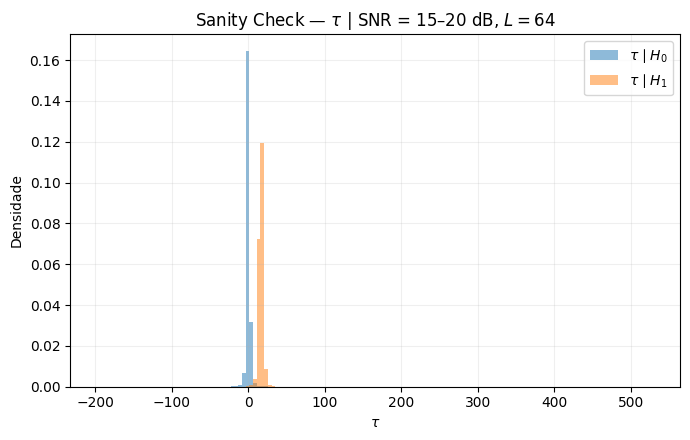

In [8]:
# ==============================================================
# SANITY CHECK — TAU H0/H1
# ==============================================================

# Seleciona apenas a faixa de SNR desejada.
# Não inferimos L a partir de Y_eq, pois Y_eq possui 64 colunas
# e pode conter zeros que não representam padding.
mask_snr = (SNR_arr >= 15) & (SNR_arr <= 20)

mask_H1 = mask_snr & (LBL == 1)
mask_H0 = mask_snr & (LBL == 0)

tau_h1 = TAU_eq[mask_H1]
tau_h0 = TAU_eq[mask_H0]

print(f"Sanity plot — SNR 15–20 dB, L={L_FIXED}")
print(f"H1 samples: {len(tau_h1):,}")
print(f"H0 samples: {len(tau_h0):,}")

if len(tau_h1) == 0 or len(tau_h0) == 0:
    raise RuntimeError(
        "Sanity check sem amostras H0/H1. "
        "Verifique SNR_arr e LBL."
    )

print(
    f"H1: mean={tau_h1.mean():.3f}, "
    f"std={tau_h1.std():.3f}"
)

print(
    f"H0: mean={tau_h0.mean():.3f}, "
    f"std={tau_h0.std():.3f}"
)

# Faixa segura para o histograma
all_tau = np.concatenate([tau_h0, tau_h1])

x_lo = np.nanmin(all_tau)
x_hi = np.nanmax(all_tau)

if not np.isfinite(x_lo) or not np.isfinite(x_hi):
    raise RuntimeError(
        "TAU contém valores não finitos."
    )

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.hist(
    tau_h0,
    bins=150,
    alpha=0.5,
    range=(x_lo, x_hi),
    density=True,
    label=r"$\tau \mid H_0$"
)

ax.hist(
    tau_h1,
    bins=150,
    alpha=0.5,
    range=(x_lo, x_hi),
    density=True,
    label=r"$\tau \mid H_1$"
)

ax.set_xlabel(r"$\tau$")
ax.set_ylabel("Densidade")
ax.set_title(
    rf"Sanity Check — $\tau$ | SNR = 15–20 dB, $L={L_FIXED}$"
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

Computing AWGN β vs L  (K=512, SNR=10dB, η=1e-07)
Theoretical: closed-form Φ(Q⁻¹(η)−D)
Monte Carlo: AWGN h=h_fake=1,  N=10000 per point


β vs L: 100%|██████████| 15/15 [00:04<00:00,  3.36it/s]


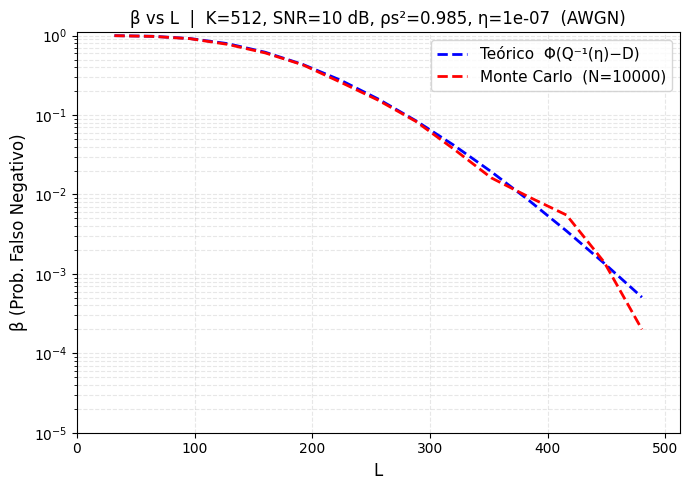

AWGN β at L=512 : 5.08e-04  (Fig 4.6 target: ~3×10⁻⁴)
AWGN β at L=384 : 8.42e-03  (Fig 4.6 target: ~10⁻²)
AWGN β at L=256 : 1.59e-01  (Fig 4.6 target: ~10⁻¹)
Computing Rayleigh fixed-threshold β vs L  (K=512, SNR=10dB, η=1e-07)


Rayleigh β vs L: 100%|██████████| 15/15 [00:00<00:00, 66.32it/s]


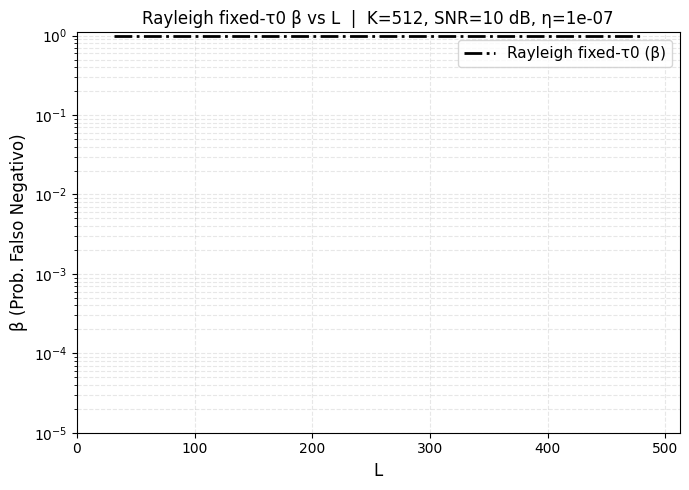

Rayleigh fixed-τ0 α (empirical) at L=512 : 0.00e+00
Rayleigh fixed-τ0 β at L=512 : 1.00e+00
Rayleigh τ0/L at L=512 : 8.24e+01 (ratio to tag energy)


In [9]:
# ======================================================================
# 8. VALIDATION — β vs L  (compare with Fig. 4.6, João's dissertation)
#    This section now separates two regimes:
#      1) AWGN validation (h_fake = 1, compatible with Fig. 4.6)
#      2) Rayleigh fixed-threshold validation (fixed τ0, α averaged over
#         Rayleigh fading, matching the pages 1-5 model and its 1/SNR floor)
# ======================================================================
from scipy.stats import norm as sp_norm_v

K_VAL   = 512
SNR_VAL = 10
ETA_VAL = 1e-7
RHO_S_VAL = np.sqrt(0.985)
RHO_T_VAL = np.sqrt(3 * (1 - RHO_S_VAL**2))
Omega = 1.0
N_MC    = 10_000   # samples per L — AWGN is fast, no per-realization variance issue

L_values = list(range(32, 512, 32))

# ------------------------------------------------------------------
# 8A. AWGN validation (h = 1) — reproduces Fig. 4.6 of the dissertation.
#      This is intentionally the AWGN-equivalent model used in the notes.
# ------------------------------------------------------------------

def fnr_theoretical_awgn(L, rho_t, snr_db, eta, sigma2tag=1/3):
    """Closed-form FNR for AWGN channel (h = h_fake = 1)."""
    sigma2w = 1.0 / 10**(snr_db / 10)
    C = sigma2tag * sigma2w * L / rho_t**2   # = Var[τ|H1] at h=1
    D = (L / 3) / np.sqrt(C)                 # = E[τ|H1] / σ[τ|H1]
    return float(sp_norm_v.cdf(sp_norm_v.isf(eta) - D))

def compute_fnr_awgn_mc(L, K, N, rho_s, rho_t, snr_db, eta):
    """Monte Carlo FNR for AWGN channel (h = h_fake = 1)."""
    sigma2w   = 1.0 / 10**(snr_db / 10)
    sigma2tag = 1.0 / 3.0

    msgs  = np.random.randint(0, 2, (N, L)) * 2 - 1
    keys  = np.random.randint(0, 2, (N, K), dtype=np.uint8)
    seeds = np.array([_compute_seed(msgs[i], keys[i], K) for i in range(N)])
    tags  = generate_tags_batch(seeds, L, K)          # (N, L), var≈1/3

    x_h1  = rho_s * msgs + rho_t * tags
    w_h1  = np.random.normal(0, np.sqrt(sigma2w), (N, L))
    y_eq1 = x_h1 + w_h1                               # h=1 → no division
    tau_h1 = np.sum((y_eq1 - rho_s * msgs) * tags, axis=1) / rho_t

    sigma_v = np.sqrt(sigma2tag * sigma2w * L) / rho_t  # h_fake=1
    tau0    = sigma_v * sp_norm_v.isf(eta)

    return float(np.mean(tau_h1 < tau0))

# --- Compute AWGN curves ---
print(f"Computing AWGN β vs L  (K={K_VAL}, SNR={SNR_VAL}dB, η={ETA_VAL})")
print(f"Theoretical: closed-form Φ(Q⁻¹(η)−D)")
print(f"Monte Carlo: AWGN h=h_fake=1,  N={N_MC} per point")

fnr_th = []
fnr_mc = []
for L_val in tqdm(L_values, desc="β vs L"):
    fnr_th.append(fnr_theoretical_awgn(L_val, RHO_T_VAL, SNR_VAL, ETA_VAL))
    fnr_mc.append(max(
        compute_fnr_awgn_mc(L_val, K_VAL, N_MC, RHO_S_VAL, RHO_T_VAL, SNR_VAL, ETA_VAL),
        1e-5))

# --- Plot AWGN results ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.semilogy(L_values, fnr_th, '--b', linewidth=2,     label='Teórico  Φ(Q⁻¹(η)−D)')
ax.semilogy(L_values, fnr_mc, '--r', linewidth=2,     label=f'Monte Carlo  (N={N_MC})')
ax.set_xlabel('L', fontsize=12)
ax.set_ylabel('β (Prob. Falso Negativo)', fontsize=12)
ax.set_title(f'β vs L  |  K={K_VAL}, SNR={SNR_VAL} dB, ρs²=0.985, η={ETA_VAL}  (AWGN)', fontsize=12)
ax.set_xlim([0, 512]);  ax.set_ylim([1e-5, 1.1])
ax.grid(True, which='both', alpha=0.3, linestyle='--')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(str(visualizations_dir / "NN01_beta_vs_L_validation_awgn.png"), dpi=120)
plt.show()

print(f"AWGN β at L=512 : {fnr_th[-1]:.2e}  (Fig 4.6 target: ~3×10⁻⁴)")
print(f"AWGN β at L=384 : {fnr_th[L_values.index(384)]:.2e}  (Fig 4.6 target: ~10⁻²)")
print(f"AWGN β at L=256 : {fnr_th[L_values.index(256)]:.2e}  (Fig 4.6 target: ~10⁻¹)")

# ------------------------------------------------------------------
# 8B. Rayleigh fixed-threshold validation (pages 1-5 model).
#      Here τ0 is fixed once, and α is averaged over the Rayleigh fading
#      distribution for the same target value. This is the regime where
#      the 1/SNR floor appears.
# ------------------------------------------------------------------

def alpha_beta_rayleigh(t2, tau0, rho_t, sigma_w2, Omega=1.0):
    A = (tau0 ** 2 * rho_t ** 2) / (t2 * sigma_w2)
    alpha_i = 0.5 * (1.0 - np.sqrt(A * Omega / (2.0 + A * Omega)))
    B = ((tau0 - t2) ** 2 * rho_t ** 2) / (t2 * sigma_w2)
    term = 0.5 * (1.0 - np.sqrt(B * Omega / (2.0 + B * Omega)))
    beta_i = np.where(tau0 >= t2, 1.0 - term, term)
    return float(alpha_i.mean()), float(beta_i.mean())

def solve_tau0_for_target_alpha(alpha_target, t2_mean, rho_t, sigma_w2, Omega=1.0):
    k = 2.0 * (1.0 - 2.0 * alpha_target) ** 2 / (1.0 - (1.0 - 2.0 * alpha_target) ** 2)
    A = k / Omega
    return np.sqrt(A * t2_mean * sigma_w2 / rho_t ** 2)

def compute_rayleigh_beta_fixed_tau0(L, K, N, rho_s, rho_t, snr_db, eta):
    sigma2w = 1.0 / 10**(snr_db / 10)
    seeds = np.random.uniform(-1.0, 1.0, size=N)
    tags  = generate_tags_batch(seeds, L, K)
    t2    = np.sum(tags.astype(np.float64) ** 2, axis=1)
    tau0  = solve_tau0_for_target_alpha(eta, t2.mean(), rho_t, sigma2w, Omega)

    # explicit Monte Carlo check with Rayleigh fading
    h2  = np.random.exponential(scale=Omega, size=N)
    std = np.sqrt(t2 * sigma2w / (rho_t ** 2 * h2))

    tau_h0 = np.random.normal(0.0, std)
    tau_h1 = np.random.normal(t2, std)

    alpha_emp = float(np.mean(tau_h0 > tau0))
    beta_emp  = float(np.mean(tau_h1 < tau0))
    return tau0, alpha_emp, beta_emp

# --- Compute Rayleigh fixed-threshold curves ---
print(f"Computing Rayleigh fixed-threshold β vs L  (K={K_VAL}, SNR={SNR_VAL}dB, η={ETA_VAL})")
rayleigh_beta = []
rayleigh_tau0 = []
rayleigh_alpha = []
for L_val in tqdm(L_values, desc="Rayleigh β vs L"):
    tau0_r, alpha_r, beta_r = compute_rayleigh_beta_fixed_tau0(
        L_val, K_VAL, 2000, RHO_S_VAL, RHO_T_VAL, SNR_VAL, ETA_VAL)
    rayleigh_beta.append(beta_r)
    rayleigh_tau0.append(tau0_r)
    rayleigh_alpha.append(alpha_r)

fig, ax = plt.subplots(figsize=(7, 5))
ax.semilogy(L_values, rayleigh_beta, '-.k', linewidth=2, label='Rayleigh fixed-τ0 (β)')
ax.set_xlabel('L', fontsize=12)
ax.set_ylabel('β (Prob. Falso Negativo)', fontsize=12)
ax.set_title(f'Rayleigh fixed-τ0 β vs L  |  K={K_VAL}, SNR={SNR_VAL} dB, η={ETA_VAL}', fontsize=12)
ax.set_xlim([0, 512]);  ax.set_ylim([1e-5, 1.1])
ax.grid(True, which='both', alpha=0.3, linestyle='--')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(str(visualizations_dir / "NN01_beta_vs_L_validation_rayleigh.png"), dpi=120)
plt.show()

print(f"Rayleigh fixed-τ0 α (empirical) at L=512 : {rayleigh_alpha[-1]:.2e}")
print(f"Rayleigh fixed-τ0 β at L=512 : {rayleigh_beta[-1]:.2e}")
print(f"Rayleigh τ0/L at L=512 : {rayleigh_tau0[-1]/512:.2e} (ratio to tag energy)")

## Summary — v4 (z_eq Corrected + Rayleigh Fading)

### 📊 Dataset Output (`dataset_DNN_yeq_0_30dB.h5`)

| Item | Value |
|------|-------|
| **Location** | `results/data/dataset_DNN_yeq_0_30dB.h5` (~1.84 GB) |
| **Total samples** | ~350k (300k base + 1.5× oversampling SNR < 10 dB) |
| **SNR range** | 0–30 dB (6 stratified bins) |
| **L range** | 512–64 (zero-padded to 64) |
| **H1/H0 balance** | 50%/50% (strictly alternating generation) |
| **Train/Val/Test split** | 80/10/10 (stratified by label) |

### 📌 Primary Features (Rayleigh Fading + AWGN)

| Feature | Type | Shape | Description |
|---------|------|-------|-------------|
| **y_eq** | float32 | (N, 1024) | Equalized received signal: `y/h` (reference raw vector) |
| **z_eq** ✅ | float32 | (N, 1024) | **Normalized residual:** `(y/h − ρₛ·msg) / ρₜ` — **CORRECTED** |
| **tau_eq** | float32 | (N,) | Classical correlator (Xie 2021): `y_eq · conj(tag)` |
| **h** | float32 | (N,) | Rayleigh channel gain (magnitude) |
| **snr** | float32 | (N,) | Per-sample SNR [dB] |
| **y** | int8 | (N,) | Ground truth label: 1=H1 (auth), 0=H0 (attacker) |

### 🔧 **Critical Correction**

**z_eq Formula Fix (v3 → v4):**
- ❌ **BEFORE (v3):** `z_eq = y/h − ρₛ·msg` (missing normalization)
- ✅ **AFTER (v4):** `z_eq = (y/h − ρₛ·msg) / ρₜ` (normalized by TAG power)

**Why it matters:**
- Without `/ρₜ`, z_eq amplitude was ~4.7× too large (ρₜ ≈ 0.212)
- Normalization ensures TAG and noise have comparable amplitudes
- Aligns with classical correlator τ_eq (both now well-scaled)

### ⚖️ Power Allocation

| Parameter | Value | Role |
|-----------|-------|------|
| **ρₛ** | √0.985 ≈ 0.9925 | Message power scaling |
| **ρₜ** | √(3(1−ρₛ²)) ≈ 0.2121 | TAG power scaling (assuming E[tag²]≈1/3) |
| **Constraint** | ρₛ² + ρₜ²·E[tag²] = 1.0 | Total power = 1 ✓ |

### 📈 Channel Model

- **Fading:** Rayleigh (h ~ Rayleigh(σ=1))
- **Noise:** AWGN (w ~ N(0, σ²), σ determined by SNR target)
- **H1 signal:** y = h·(ρₛ·msg + ρₜ·tag) + w
- **H0 signal:** y = h·msg + w (no TAG)

### 🧪 Quality Checks (Cell 9 & 10)

✅ **Cell 9 — Statistical Validation:**
- z_eq distribution check (H1 vs H0, various SNRs)
- Signal/noise separation verified
- Classical detector (τ_eq) performance baseline

✅ **Cell 10 — Theoretical Analysis:**
- **Rayleigh fading floor:** α decays as **1/(4·SNR)** (polynomial, not exponential)
  - Fixed channel-blind threshold cannot overcome this limit
  - Root cause: Rayleigh fading introduces deep fades where h ≈ 0
  - With fixed threshold, low h samples fail detection regardless of SNR
- **AWGN baseline:** α decays exponentially (for comparison)
- **Implication:** Networks must learn adaptive strategies to mitigate fading

### 🚀 Next Notebooks

- **NN_02_DNN_Correlator_GPU:** Train 1D DNN on `z_eq` → classify H1 vs H0
  - Single-input variant: Tests if normalized z_eq alone suffices
- **NN_02b_4feat_DNN_Aligned:** Compare against feature-based approach
  - Input: [τ_eq, ĥ, SNR, E] extracted from y_eq
  - Performance baseline: AUC ~0.9998 (due to explicit channel gain ĥ)
- **NN_02c_Ablation_z_eq_variants:** Systematic ablation study
  - Variant A: z_eq[1024] only
  - Variant B: z_eq[1024] + h[1]
  - Variant C: z_eq[1024] + h[1] + SNR[1]
  - Variant D: z_eq[1024] + τ_eq[1]
  - Question: Does z_eq alone achieve near-optimal performance? (D3F theory prediction)